<a href="https://colab.research.google.com/github/redrosesarecool/staz/blob/main/krzywa_rotacji.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Unsupervised learning (e.g., DBSCAN, HDBSCAN) to detect distinct kinematic groups, possibly separating gas clouds from different stellar populations automatically.

# Dane

In [ ]:
import pandas as pd

file_path = "/content/drive/My Drive/r_v_montecarlo.dat"
df_all = pd.read_csv(file_path, delim_whitespace=True)
print(df_all.head())

/tmp/ipython-input-904907318.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_all = pd.read_csv(file_path, delim_whitespace=True)


         R          V
0  2.16208  205.52478
1  2.30257  200.57954
2  2.44236  196.41595
3  2.58141  197.63277
4  2.71967  197.12877


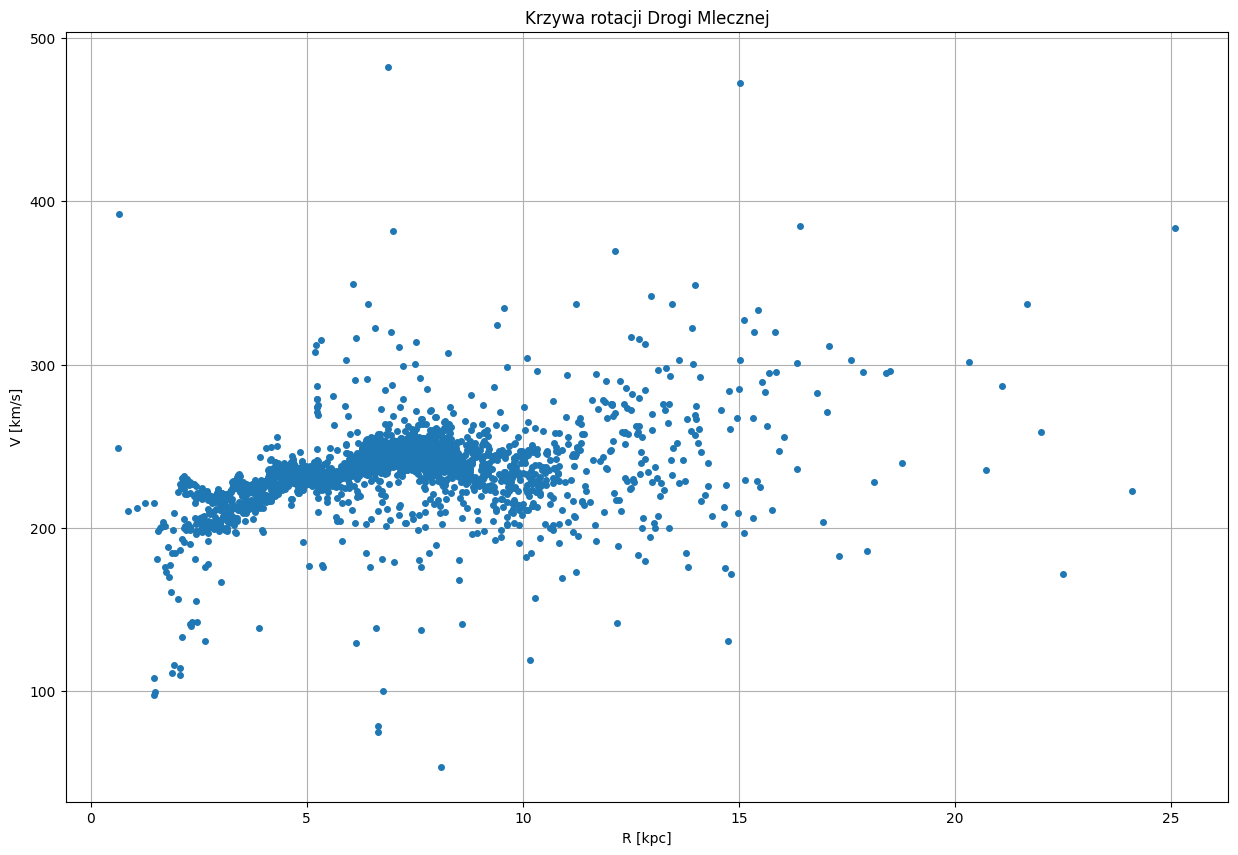

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# wykres R vs V
plt.figure(figsize=(15,10))
plt.plot(df_all["R"], df_all["V"], 'o', markersize=4)
plt.xlabel("R [kpc]")
plt.ylabel("V [km/s]")
plt.title("Krzywa rotacji Drogi Mlecznej")
plt.grid(True)
plt.show()

# DBSCAN w 2D

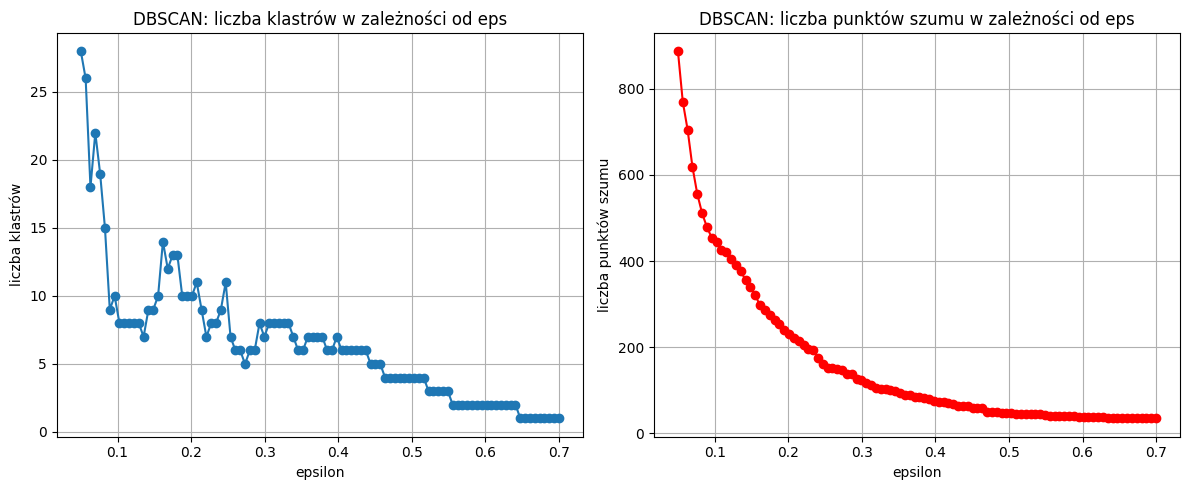

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# skalowanie danych
X = df_all[["R", "V"]].values
X_scaled = StandardScaler().fit_transform(X)

# parametry
eps_values = np.linspace(0.05, 0.7, 100)  # 100 kroków od 0.05 do 0.7
min_samples = 5

# listy do przechowywania wyników
n_clusters_list = []
n_noise_list = []

# pętla po epsilon
for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=min_samples).fit(X_scaled)
    labels = db.labels_

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    n_clusters_list.append(n_clusters)
    n_noise_list.append(n_noise)

# wykres
plt.figure(figsize=(12,5))

# liczba klastrów
plt.subplot(1,2,1)
plt.plot(eps_values, n_clusters_list, marker="o")
plt.xlabel("epsilon")
plt.ylabel("liczba klastrów")
plt.title("DBSCAN: liczba klastrów w zależności od eps")
plt.grid(True)

# liczba punktów szumu
plt.subplot(1,2,2)
plt.plot(eps_values, n_noise_list, marker="o", color="red")
plt.xlabel("epsilon")
plt.ylabel("liczba punktów szumu")
plt.title("DBSCAN: liczba punktów szumu w zależności od eps")
plt.grid(True)

plt.tight_layout()
plt.show()

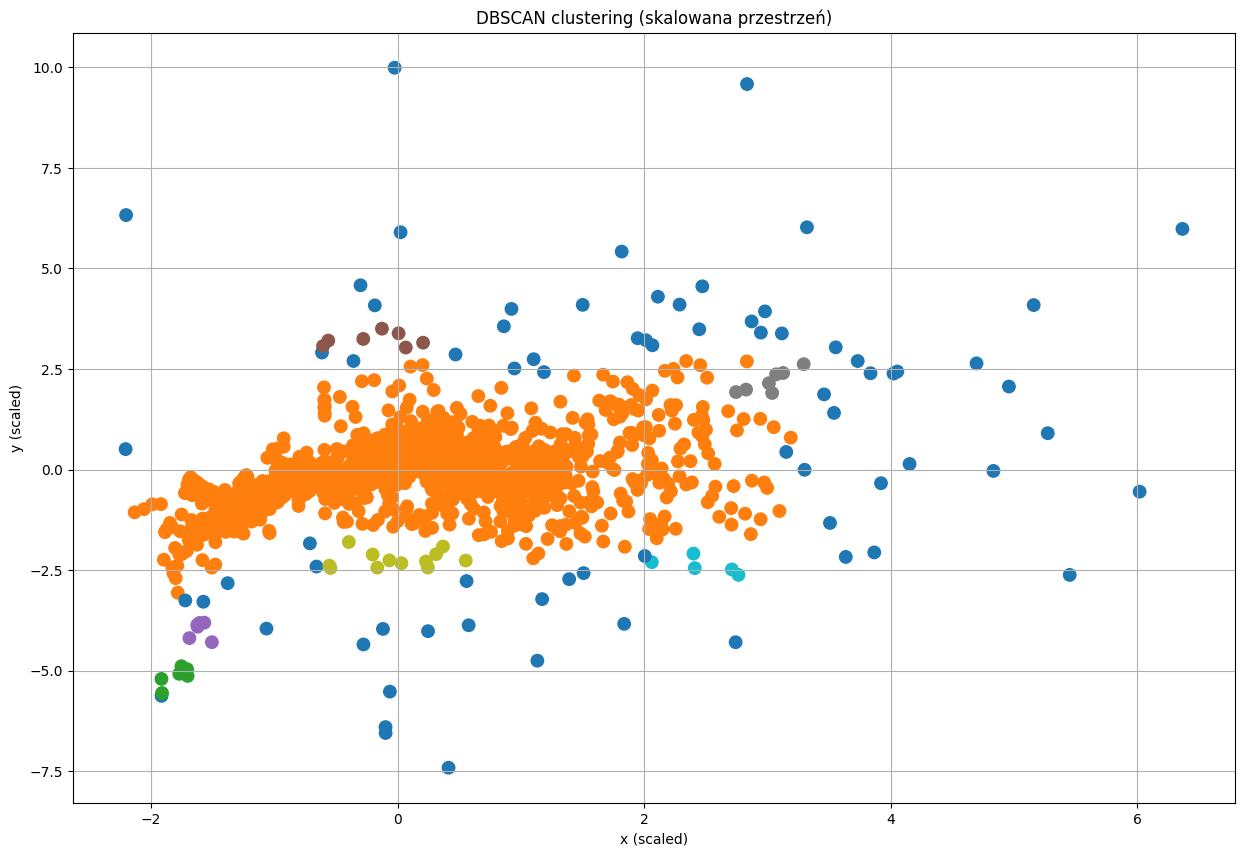

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

X = df_all[["R", "V"]].values
X_scaled = StandardScaler().fit_transform(X)

# DBSCAN
db = DBSCAN(eps=0.4, min_samples=5).fit(X_scaled)

# etykiety klastrów
labels = db.labels_
df_all["cluster"] = labels

# wykres
plt.figure(figsize=(15,10))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=df_all["cluster"], cmap="tab10", s=80)
plt.xlabel("x (scaled)")
plt.ylabel("y (scaled)")
plt.title("DBSCAN clustering (skalowana przestrzeń)")
plt.grid(True)
plt.show()

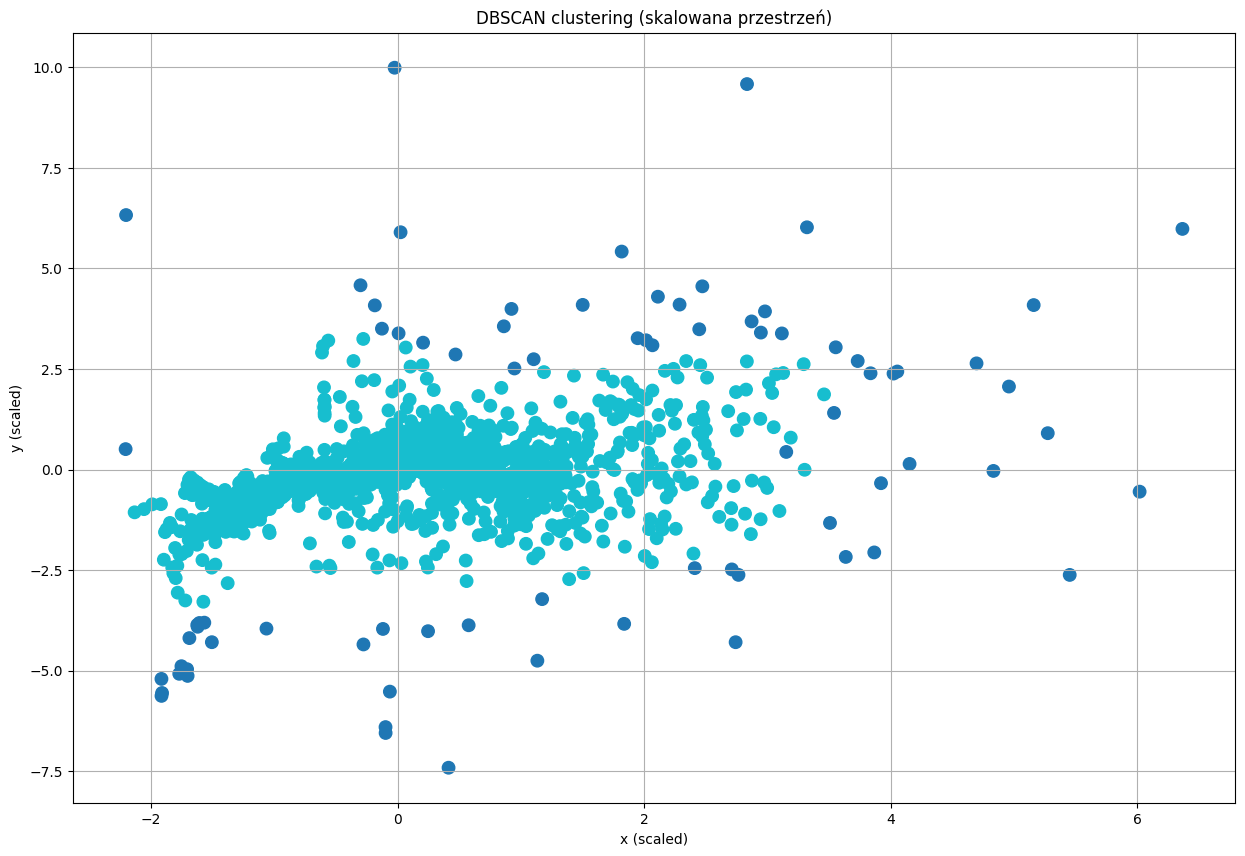

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

X = df_all[["R", "V"]].values
X_scaled = StandardScaler().fit_transform(X)

# DBSCAN
db = DBSCAN(eps=0.6, min_samples=10).fit(X_scaled)

# etykiety klastrów
labels = db.labels_
df_all["cluster"] = labels

# wykres
plt.figure(figsize=(15,10))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=df_all["cluster"], cmap="tab10", s=80)
plt.xlabel("x (scaled)")
plt.ylabel("y (scaled)")
plt.title("DBSCAN clustering (skalowana przestrzeń)")
plt.grid(True)
plt.show()

# Krzywa rotacji gwiazd

In [ ]:
file_path = "/content/drive/My Drive/r_v_montecarlo-gwiazdy.dat"
df_stars = pd.read_csv(file_path, delim_whitespace=True)
print(df_stars.head())

/tmp/ipython-input-1364008935.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_stars = pd.read_csv(file_path, delim_whitespace=True)


          R          V
0   9.26153  226.40205
1   9.04285  230.36369
2   9.97287  247.06935
3  10.12874  265.07508
4   9.72798  228.31482


Cel: oddzielić różowe od niebieskich

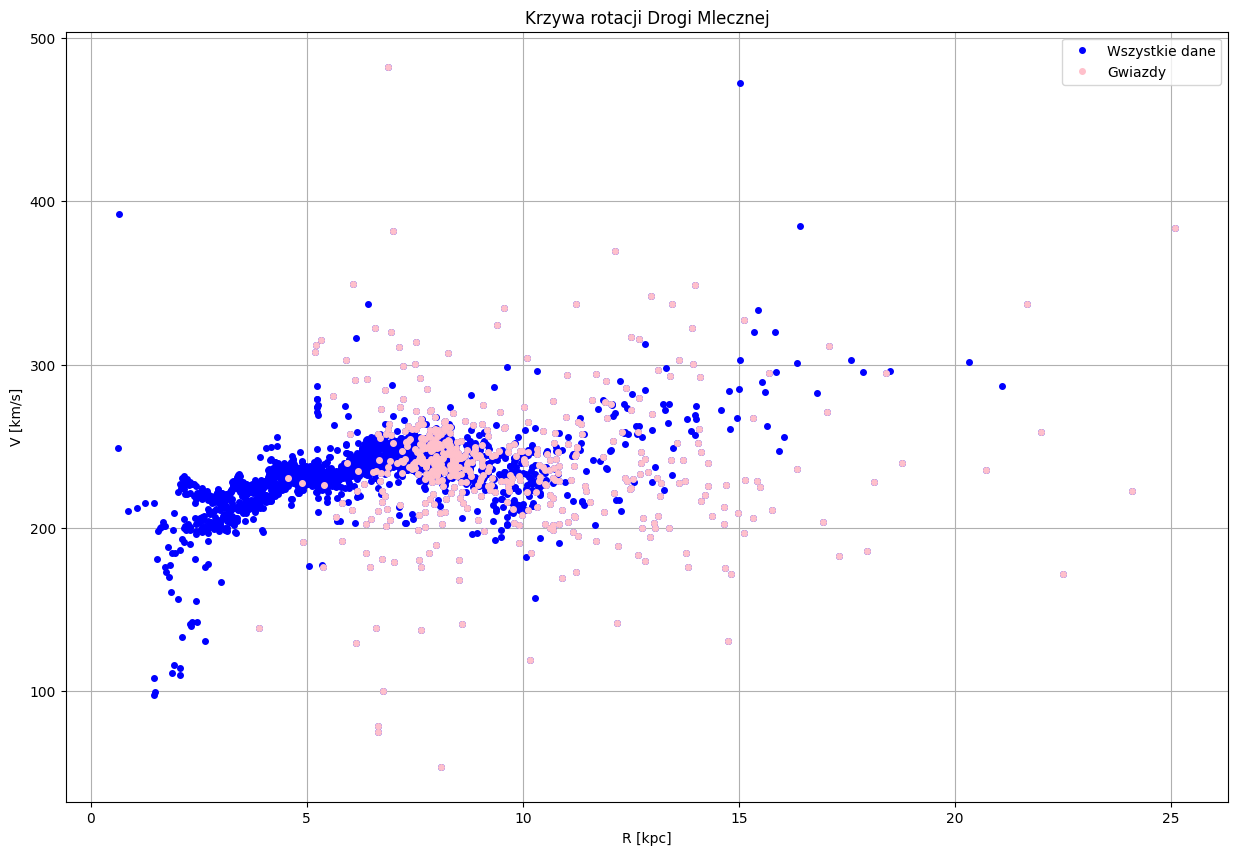

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# wykres z dwoma zestawami danych
plt.figure(figsize=(15,10))

# wszystkie dane
plt.plot(df_all["R"], df_all["V"], 'o', markersize=4, color="blue", label="Wszystkie dane")

# dane rotacji gwiazd
plt.plot(df_stars["R"], df_stars["V"], 'o', markersize=4, color="pink", label="Gwiazdy")

plt.xlabel("R [kpc]")
plt.ylabel("V [km/s]")
plt.title("Krzywa rotacji Drogi Mlecznej")
plt.grid(True)
plt.legend()
plt.show()


# DBSCAN w 3D

In [ ]:
import pandas as pd

file_path = "/content/drive/My Drive/r_v_z.dat"
df_rvz = pd.read_csv(file_path, delim_whitespace=True)
print(df_rvz.head())

/tmp/ipython-input-3066409719.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_rvz = pd.read_csv(file_path, delim_whitespace=True)


         R          V    z
0  2.15659  205.46459  0.0
1  2.29672  200.51650  0.0
2  2.43616  196.35007  0.0
3  2.57486  197.56407  0.0
4  2.71277  197.05728  0.0


In [ ]:
import pandas as pd
import plotly.express as px
from google.colab import drive

# wykres 3D

fig = px.scatter_3d(
    df_rvz,
    x="R",
    y="V",
    z="z",
    color=None,
    size_max=5,
    opacity=0.6,
    labels={"R":"R [kpc]", "V":"vRt [km/s]", "z":"z [kpc]"},
    title="Wykres 3D: R, V, z"
)

fig.update_layout(
    scene=dict(
        xaxis_title='R [kpc]',
        yaxis_title='vRt [km/s]',
        zaxis_title='z [kpc]',
        aspectmode='manual',
        aspectratio=dict(x=2, y=2, z=0.5)  # proporcje osi
    ),
    width=1000,
    height=700
)

fig.show()

In [ ]:
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import plotly.express as px

# macierz cech 3D
X = df_rvz[["R", "V", "z"]].values
X_scaled = StandardScaler().fit_transform(X)

# DBSCAN
db = DBSCAN(eps=0.065, min_samples=20).fit(X_scaled)
labels = db.labels_
df_rvz["cluster"] = labels.astype(str)

df_rvz["populacja"] = df_rvz["z"].apply(lambda z: "gaz" if abs(z) < 0.065 else "gwiazdy")
print(df_rvz["populacja"].value_counts())

# wykres 3D
fig = px.scatter_3d(
    df_rvz,
    x=X_scaled[:,0],
    y=X_scaled[:,1],
    z=X_scaled[:,2],
    color="populacja",
    symbol="populacja",
    labels={"x":"R (scaled)", "y":"V (scaled)", "z":"z (scaled)"},
    title="DBSCAN clustering w 3D (R, V, z)",
    opacity=0.7
)

fig.update_layout(
    scene=dict(
        xaxis_title='R [kpc]',
        yaxis_title='vRt [km/s]',
        zaxis_title='z [kpc]',
        aspectmode='manual',
        aspectratio=dict(x=2, y=2, z=0.5)  # proporcje osi
    ),
    width=1000,
    height=700
)
fig.show()

print(df_rvz["cluster"].value_counts())

populacja
gaz        2287
gwiazdy     518
Name: count, dtype: int64


cluster
-1    1727
1      439
6      221
0      141
3       92
2       89
4       48
5       48
Name: count, dtype: int64


In [ ]:
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import plotly.express as px
import plotly.graph_objects as go

# DBSCAN
X = df_rvz[["R", "V", "z"]].values
X_scaled = StandardScaler().fit_transform(X)

db = DBSCAN(eps=0.066, min_samples=20).fit(X_scaled)
labels = db.labels_
df_rvz["cluster"] = labels.astype(str)

df_rvz["populacja"] = df_rvz["z"].apply(lambda z: "gaz" if abs(z) < 0.066 else "gwiazdy")
print(df_rvz["populacja"].value_counts())

# wykres
fig = px.scatter_3d(
    df_rvz,
    x=X_scaled[:,0],
    y=X_scaled[:,1],
    z=X_scaled[:,2],
    color="populacja",
    symbol="populacja",
    labels={"x":"R (scaled)", "y":"V (scaled)", "z":"z (scaled)"},
    title="DBSCAN clustering w 3D (R, V, z)",
    opacity=0.7
)

# dane gwiazd (wiadomo z danych)
subset = df_rvz.iloc[2217:2723]

# ile punktów z subset to gwiazdy
subset_stars = subset[subset["populacja"] == "gwiazdy"]

print(f"Liczba punktów w podzbiorze: {subset.shape[0]}")
print(f"Liczba punktów gwiazd w podzbiorze: {subset_stars.shape[0]}")
print(f"Udział gwiazd w podzbiorze: {subset_stars.shape[0]/subset.shape[0]*100:.2f}%")


# wykres z danymi, które znamy
fig.add_trace(go.Scatter3d(
    x=(subset[["R", "V", "z"]].values[:,0] - X[:,0].mean()) / X[:,0].std(),  # standaryzacja jak X_scaled
    y=(subset[["R", "V", "z"]].values[:,1] - X[:,1].mean()) / X[:,1].std(),
    z=(subset[["R", "V", "z"]].values[:,2] - X[:,2].mean()) / X[:,2].std(),
    mode="markers",
    marker=dict(size=5, color="pink", symbol="circle"),
    name="Wiersze 2218–2723"
))

fig.update_layout(
    scene=dict(
        xaxis_title='R [scaled]',
        yaxis_title='V [scaled]',
        zaxis_title='z [scaled]',
        aspectmode='manual',
        aspectratio=dict(x=2, y=2, z=0.5)
    ),
    width=1000,
    height=700
)

fig.show()

print(df_rvz["cluster"].value_counts())

populacja
gaz        2296
gwiazdy     509
Name: count, dtype: int64
Liczba punktów w podzbiorze: 506
Liczba punktów gwiazd w podzbiorze: 293
Udział gwiazd w podzbiorze: 57.91%


cluster
-1    1715
1      447
6      221
0      141
3       92
2       91
5       50
4       48
Name: count, dtype: int64


In [ ]:
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

X = df_rvz[["R", "V", "z"]].values
X_scaled = StandardScaler().fit_transform(X)

# podzbiór gwiazd "prawdziwych"
subset = df_rvz.iloc[2217:2723].copy()
true_idx = set(subset.index)  # indeksy globalne

best_score = -1
best_params = None

for eps in np.linspace(0.01, 0.1, 100):
    for min_samples in [5, 10, 15, 20, 30]:
        db = DBSCAN(eps=eps, min_samples=min_samples).fit(X_scaled)
        labels = db.labels_

        df_rvz["cluster_tmp"] = labels

        # zbiór punktów oznaczonych jako szum
        noise_idx = set(df_rvz.index[df_rvz["cluster_tmp"] == -1])

        # prawdziwie pozytywne = przecięcie
        TP = len(noise_idx & true_idx)
        # fałszywie pozytywne = dodatkowe szumy, które nie są w Twoim zbiorze
        FP = len(noise_idx - true_idx)
        # fałszywie negatywne = gwiazdy z Twojego zbioru, które nie weszły do szumu
        FN = len(true_idx - noise_idx)

        # metryki
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision+recall) > 0 else 0

        if f1 > best_score:
            best_score = f1
            best_params = (eps, min_samples, TP, FP, FN, precision, recall)

print(f"✅ Najlepsze parametry: eps={best_params[0]:.3f}, min_samples={best_params[1]}")
print(f"   Pokrycie (recall): {best_params[6]*100:.1f}%")
print(f"   Czystość (precision): {best_params[5]*100:.1f}%")
print(f"   F1-score: {best_score:.3f}")
print(f"   TP={best_params[2]}, FP={best_params[3]}, FN={best_params[4]}")

✅ Najlepsze parametry: eps=0.091, min_samples=5
   Pokrycie (recall): 92.9%
   Czystość (precision): 44.1%
   F1-score: 0.598
   TP=470, FP=596, FN=36


In [ ]:
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

X = df_rvz[["R", "V", "z"]].values
X_scaled = StandardScaler().fit_transform(X)

# podzbiór gwiazd "prawdziwych"
subset = df_rvz.iloc[2217:2723].copy()
true_idx = subset.index  # indeksy globalne

best_score = -1
best_params = None

# iteracje po eps i min_samples
for eps in np.linspace(0.01, 0.1, 100):         # zakres eps do sprawdzenia
    for min_samples in [5, 10, 15, 20, 30]:    # różne min_samples
        db = DBSCAN(eps=eps, min_samples=min_samples).fit(X_scaled)
        labels = db.labels_

        df_rvz["cluster_tmp"] = labels

        # sprawdź ile punktów w subset ma label == -1 (gwiazdy)
        subset_clusters = df_rvz.loc[true_idx, "cluster_tmp"]
        score = np.sum(subset_clusters == -1)

        if score > best_score:
            best_score = score
            best_params = (eps, min_samples)

print(f"✅ Najlepsze parametry: eps={best_params[0]:.3f}, min_samples={best_params[1]} "
      f"(gwiazd w szumie: {best_score}/{len(true_idx)})")

✅ Najlepsze parametry: eps=0.010, min_samples=5 (gwiazd w szumie: 506/506)


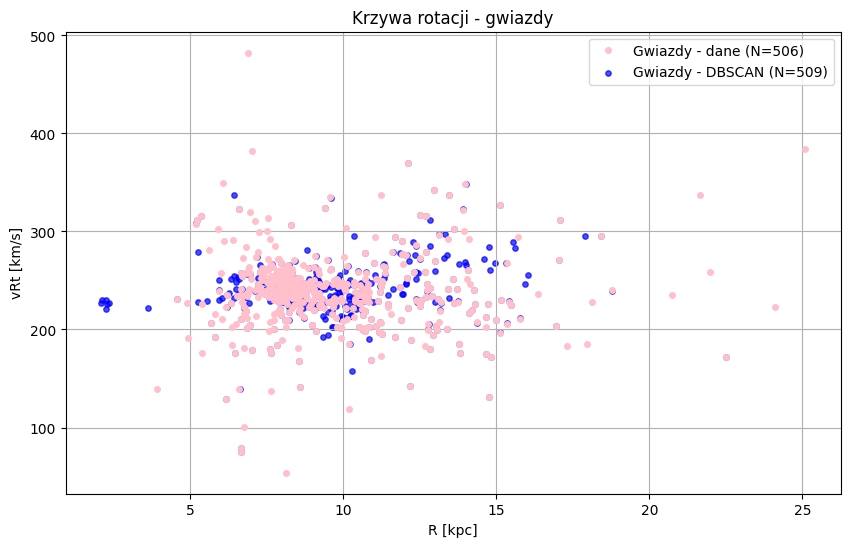

In [ ]:
import matplotlib.pyplot as plt

# tylko gwiazdy
stars = df_rvz[df_rvz["populacja"] == "gwiazdy"]

# liczebność zbiorów
n_stars_dane = df_stars.shape[0]
n_stars_dbscan = stars.shape[0]

plt.figure(figsize=(10,6))

# wykres z xdanych
plt.plot(df_stars["R"], df_stars["V"], 'o', markersize=4, color="pink", label=f"Gwiazdy - dane (N={n_stars_dane})")

# wykres z DBSCAN
plt.scatter(stars["R"], stars["V"], s=15, c="blue", alpha=0.7, label=f"Gwiazdy - DBSCAN (N={n_stars_dbscan})")

plt.xlabel("R [kpc]")
plt.ylabel("vRt [km/s]")
plt.title("Krzywa rotacji - gwiazdy")
plt.legend()
plt.grid(True)
plt.show()

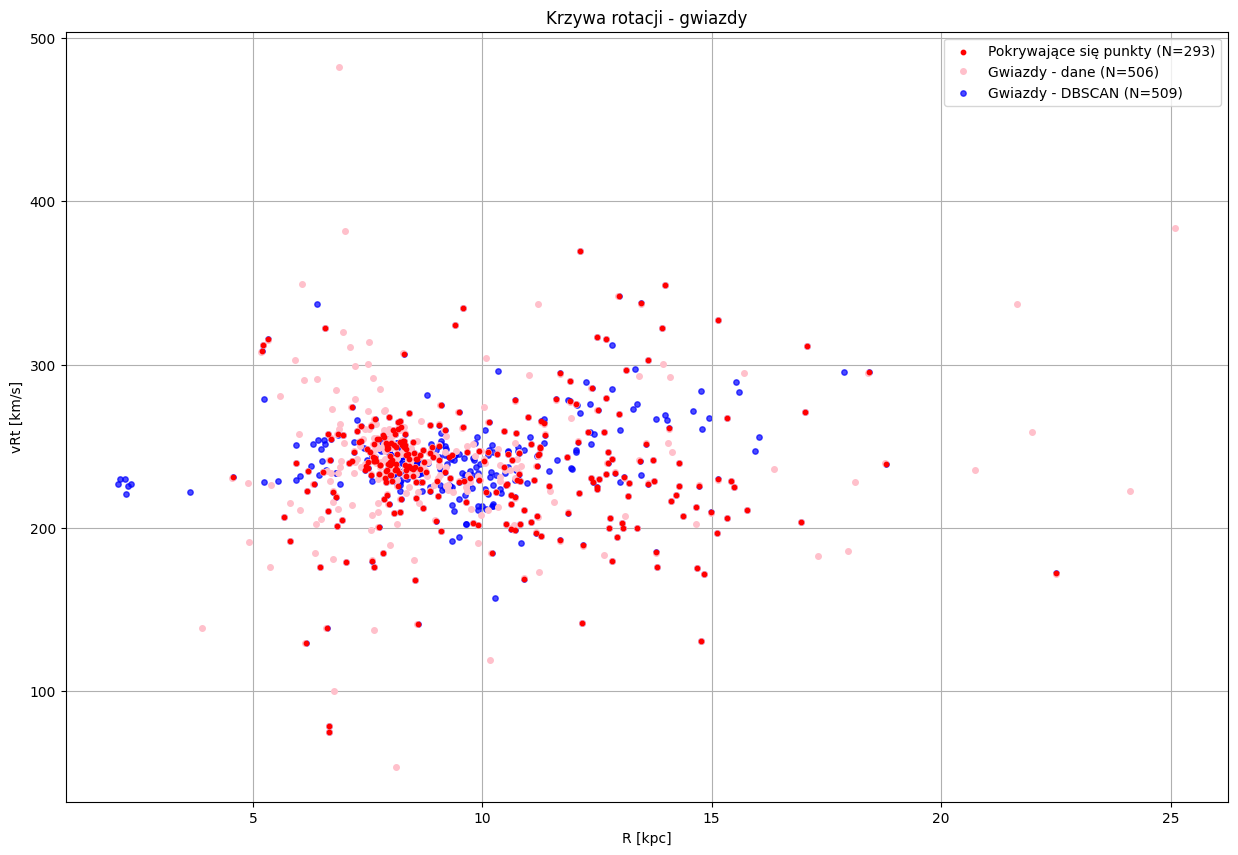

In [ ]:
import matplotlib.pyplot as plt

# tylko gwiazdy wg DBSCAN
stars = df_rvz[df_rvz["populacja"] == "gwiazdy"]

# liczebność zbiorów
n_stars_dane = df_stars.shape[0]
n_stars_dbscan = stars.shape[0]

# podzbiór gwiazd "prawdziwych"
subset = df_rvz.iloc[2217:2723]

# punkty pokrywające się dokładnie z podzbiorem
red_points = stars.loc[stars.index.isin(subset.index)]

plt.figure(figsize=(15,10))

# punkty pokrywające się z podzbiorem na czerwono
plt.scatter(red_points["R"], red_points["V"], s=10, c="red", label=f"Pokrywające się punkty (N={len(red_points)})", zorder=3)

# wykres z danych
plt.plot(df_stars["R"], df_stars["V"], 'o', markersize=4, color="pink", label=f"Gwiazdy - dane (N={n_stars_dane})", zorder=2)

# wykres DBSCAN
plt.scatter(stars["R"], stars["V"], s=15, c="blue", alpha=0.7, label=f"Gwiazdy - DBSCAN (N={n_stars_dbscan})", zorder=1)

plt.xlabel("R [kpc]")
plt.ylabel("vRt [km/s]")
plt.title("Krzywa rotacji - gwiazdy")
plt.legend()
plt.grid(True)
plt.show()


# DBSCAN z wszyskich danych


Przygotowanie danych

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import plotly.express as px

# dane
file_path = "/content/drive/My Drive/dane_obserwacyjne-kopia.dat"

column_names = [
    "R[kpc]", "err_R[kpc]", "D[kpc]", "err_D[kpc]",
    "l[deg]", "b[deg]", "x[kpc]", "y[kpc]", "z[kpc]",
    "vx[km/s]", "vRt[km/s]", "err_vRt[km/s]", "vz[km/s]",
    "wc[km/s/kpc]", "delta_wc[km/s/kpc]", "Reference"
]

df = pd.read_csv(file_path, sep=r"\s+", comment="#", names=column_names)

print("Załadowano dane:", df.shape)
print(df.head(3))

# wybór cech do klastrowani
features = ["x[kpc]", "y[kpc]", "z[kpc]", "vRt[km/s]", "vz[km/s]"]
X = df[features].values

# skalowanie danych
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Załadowano dane: (2792, 16)
   R[kpc]  err_R[kpc]  D[kpc]  err_D[kpc]  l[deg]  b[deg]  x[kpc]  y[kpc]  \
0   2.159       0.041   8.056       0.155    15.0     0.0   0.559  -2.085   
1   2.299       0.044   8.017       0.154    16.0     0.0   0.634  -2.210   
2   2.438       0.047   7.976       0.153    17.0     0.0   0.713  -2.332   

   z[kpc]  vx[km/s]  vRt[km/s]  err_vRt[km/s]  vz[km/s]  wc[km/s/kpc]  \
0     0.0   794.078    205.522            4.5      7.81        95.213   
1     0.0   727.687    200.578            4.5      7.81        87.253   
2     0.0   671.798    196.415            4.5      7.81        80.551   

   delta_wc[km/s/kpc]     Reference  
0               2.085  Fich89_Table  
1               1.958  Fich89_Table  
2               1.845  Fich89_Table  


Wykresy ilości klastrów i punktów szumu w zależności od parametru epsilon

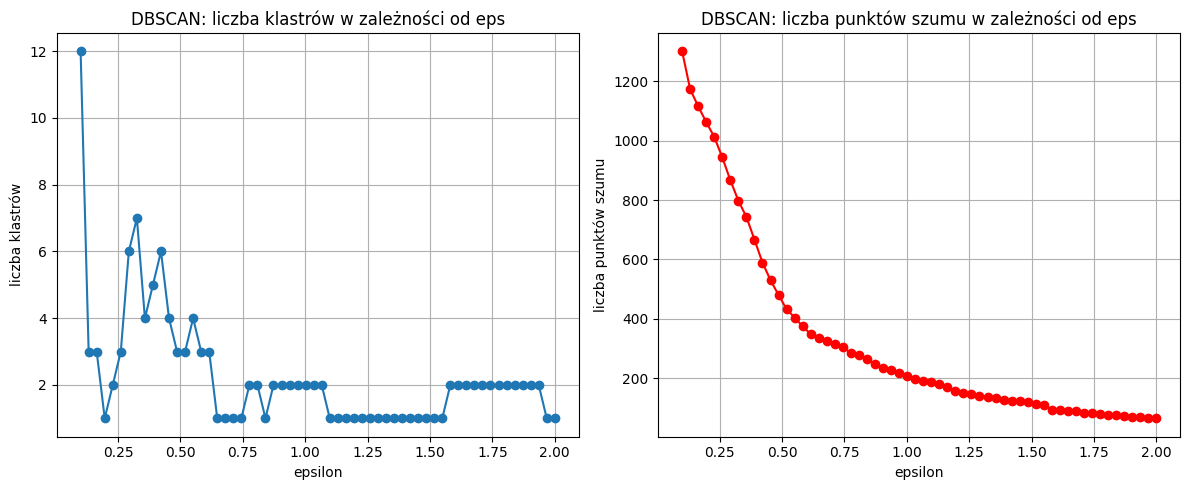

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import plotly.express as px

# przeszukiwanie eps
eps_values = np.linspace(0.1, 2.0, 60)
min_samples = 9

n_clusters_list = []
n_noise_list = []

for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=min_samples).fit(X_scaled)
    labels = db.labels_
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    n_clusters_list.append(n_clusters)
    n_noise_list.append(n_noise)

# wykresy zależności eps
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(eps_values, n_clusters_list, marker="o")
plt.xlabel("epsilon")
plt.ylabel("liczba klastrów")
plt.title("DBSCAN: liczba klastrów w zależności od eps")
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(eps_values, n_noise_list, marker="o", color="red")
plt.xlabel("epsilon")
plt.ylabel("liczba punktów szumu")
plt.title("DBSCAN: liczba punktów szumu w zależności od eps")
plt.grid(True)

plt.tight_layout()
plt.show()



DBSCAN

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import plotly.express as px

# parametry DBSCAN
eps_opt = 0.45
min_samples = 9

# DBSCAN
db = DBSCAN(eps=eps_opt, min_samples=min_samples)
labels = db.fit_predict(X_scaled)
df["cluster"] = labels

# ilość punktów w klastrach
unique, counts = np.unique(labels, return_counts=True)
print(" Rozkład klastrów (DBSCAN):")
for cl, cnt in zip(unique, counts):
    if cl == -1:
        print(f"  Klasa {cl} (szum / outliers): {cnt} punktów")
    else:
        print(f"  Klaster {cl}: {cnt} punktów")

# wykres 3d
fig = px.scatter_3d(
    df,
    x="x[kpc]", y="y[kpc]", z="z[kpc]",
    color=df["cluster"].astype(str),
    hover_data={
        "R[kpc]": True, "vRt[km/s]": True, "vz[km/s]": True, "Reference": True
    },
    title=f"DBSCAN 3D (eps={eps_opt}, min_samples={min_samples})",
    color_discrete_sequence=px.colors.qualitative.Safe
)

fig.update_traces(marker=dict(size=4, line=dict(width=0)))
fig.update_layout(
    scene=dict(
        xaxis_title="x [kpc]",
        yaxis_title="y [kpc]",
        zaxis_title="z [kpc]"
    ),
    legend_title_text="Klaster",
    template="plotly_dark"
)

fig.show()

 Rozkład klastrów (DBSCAN):
  Klasa -1 (szum / outliers): 537 punktów
  Klaster 0: 2225 punktów
  Klaster 1: 12 punktów
  Klaster 2: 11 punktów
  Klaster 3: 7 punktów


Wykres sprawdzający poprawność DBSCAN

In [23]:
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import plotly.express as px
import plotly.graph_objects as go

file_path = "/content/drive/My Drive/dane_obserwacyjne-kopia.dat"

# wczytanie linii z nagłówkami
with open(file_path) as f:
    lines = f.readlines()

# usunięcia nagłówka
header_line = [i for i, line in enumerate(lines) if line.strip().startswith("# R[kpc]")][0]
columns = lines[header_line].strip("# ").split()

# dane od następnej linii po nagłówku
df = pd.read_csv(file_path, sep=r"\s+", comment="#", names=columns, skiprows=header_line+1)
print(" Kolumny:", df.columns.tolist())

# dane
features = ["x[kpc]", "y[kpc]", "z[kpc]", "vRt[km/s]", "vz[km/s]"]
X = df[features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# DBSCAN
eps_opt = 0.45
min_samples = 9
db = DBSCAN(eps=eps_opt, min_samples=min_samples).fit(X_scaled)
df["cluster"] = db.labels_

# klastry
unique, counts = np.unique(df["cluster"], return_counts=True)
print(" Rozkład klastrów (DBSCAN):")
for cl, cnt in zip(unique, counts):
    if cl == -1:
        print(f"  Szum (-1): {cnt} punktów")
    else:
        print(f"  Klaster {cl}: {cnt} punktów")

# wykres 3d w jednostkach (kpc)
fig = px.scatter_3d(
    df,
    x="x[kpc]", y="y[kpc]", z="z[kpc]",
    color=df["cluster"].astype(str),
    hover_data={
        "R[kpc]": True,
        "vRt[km/s]": True,
        "vz[km/s]": True,
        "Reference": True
    },
    title=f"DBSCAN 3D (eps={eps_opt}, min_samples={min_samples}) — w jednostkach kpc",
    color_discrete_sequence=px.colors.qualitative.Safe
)

fig.update_traces(marker=dict(size=4, line=dict(width=0)))

# dodanie punktów prawdziwych gwiazd
subset = df.iloc[2217:2723]

fig.add_trace(go.Scatter3d(
    x=df.iloc[2217:2723]["x[kpc]"],
    y=df.iloc[2217:2723]["y[kpc]"],
    z=df.iloc[2217:2723]["z[kpc]"],
    mode="markers",
    marker=dict(
        size=6,
        symbol="circle-open",
        color="rgba(0,0,0,0)",  # przezroczyste wnętrze
        line=dict(color="pink", width=5)
    ),
    name="Wiersze 2217–2723 (poprawne gwiazdy)"
))

# styl wykresu
fig.update_layout(
    scene=dict(
        xaxis_title="x [kpc]",
        yaxis_title="y [kpc]",
        zaxis_title="z [kpc]"
    ),
    legend_title_text="Klaster", #legenda
    template="plotly_dark"
)

fig.show()

 Kolumny: ['R[kpc]', 'err_R[kpc]', 'D[kpc]', 'err_D[kpc]', 'l[deg]', 'b[deg]', 'x[kpc]', 'y[kpc]', 'z[kpc]', 'vx[km/s]', 'vRt[km/s]', 'err_vRt[km/s]', 'vz[km/s]', 'wc[km/s/kpc]', 'delta_wc[km/s/kpc]', 'Reference']
 Rozkład klastrów (DBSCAN):
  Szum (-1): 537 punktów
  Klaster 0: 2225 punktów
  Klaster 1: 12 punktów
  Klaster 2: 11 punktów
  Klaster 3: 7 punktów


Porównanie poprawności DBSCAN z danymi, które wiadomo, że są gwiazdami

In [24]:
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import plotly.express as px
import plotly.graph_objects as go

# do jakich klastrów trafiły prawdziwe gwiazdy
true_subset = df.iloc[2217:2723]
true_clusters, true_counts = np.unique(true_subset["cluster"], return_counts=True)

print("\n Ilość prawdziwych gwiazd w klastrach:")
for cl, cnt in zip(true_clusters, true_counts):
    if cl == -1:
        print(f"  Szum (-1): {cnt} gwiazd")
    else:
        print(f"  Klaster {cl}: {cnt} gwiazd")

total_true = len(true_subset)
print(f"\n Razem: {total_true} prawdziwych gwiazd")


 Ilość prawdziwych gwiazd w klastrach:
  Szum (-1): 306 gwiazd
  Klaster 0: 189 gwiazd
  Klaster 1: 3 gwiazd
  Klaster 2: 1 gwiazd
  Klaster 3: 7 gwiazd

 Razem: 506 prawdziwych gwiazd
